<a href="https://colab.research.google.com/github/MariikaVD/Laba1/blob/main/%D0%9B%D0%B0%D0%B1%D0%BE%D1%80%D0%B0%D1%82%D0%BE%D1%80%D0%BD%D0%B0_%D1%80%D0%BE%D0%B1%D0%BE%D1%82%D0%B0_%E2%84%961.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [63]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [64]:
np.random.seed(20)
n = 50

first_names = ['Марія', 'Андрій', 'Максим', 'Петро', 'Оксана',
               'Василь', 'Наталія', 'Сергій', 'Тетяна', 'Богдан']

id1 = [f'ID_{i}' for i in range(1, n + 1)]
names = np.random.choice(first_names, size=n)
ages = np.random.randint(18, 60, size=n)
df1 = pd.DataFrame({'ID': id1, 'Name': names, 'Age': ages})

occupations_list = ['Програміст', 'Лікар', 'Вчитель', 'Дизайнер',
                     'Маркетолог', 'Менеджер', 'Юрист', 'Поліцейський']
id2 = [f'ID_{i}' for i in range(1, n + 1)]
occupations = np.random.choice(occupations_list, size=n)
df2 = pd.DataFrame({'ID': id2, 'Occupation': occupations})

# об'єднання
merged = pd.merge(df1, df2, on='ID')

# категор за віком
def age_group(age):
    if age < 30:
        return 'Young'
    elif age < 50:
        return 'Adult'
    else:
        return 'Senior'

merged['Age_Group'] = merged['Age'].apply(age_group)


# зміна літер
merged['Name'] = merged['Name'].str.replace('г', 'ґ')

# довжина імені
def name_length(name):
    return len(name)

merged['Length_Name'] = merged['Name'].apply(name_length)

print(merged.head(10).to_string(index=False))

print ()

senior_count = (merged['Age_Group'] == 'Senior').sum()
print(f'Кількість рядків, що мають категорію «Senior»: {senior_count}')

   ID    Name  Age Occupation Age_Group  Length_Name
 ID_1   Петро   28    Вчитель     Young            5
 ID_2  Боґдан   51      Юрист    Senior            6
 ID_3  Оксана   39   Менеджер     Adult            6
 ID_4 Наталія   35 Маркетолог     Adult            7
 ID_5  Серґій   58   Дизайнер    Senior            6
 ID_6  Максим   36    Вчитель     Adult            6
 ID_7   Марія   38      Лікар     Adult            5
 ID_8 Наталія   48      Лікар     Adult            7
 ID_9  Тетяна   54      Юрист    Senior            6
ID_10  Василь   26 Маркетолог     Young            6

Кількість рядків, що мають категорію «Senior»: 11


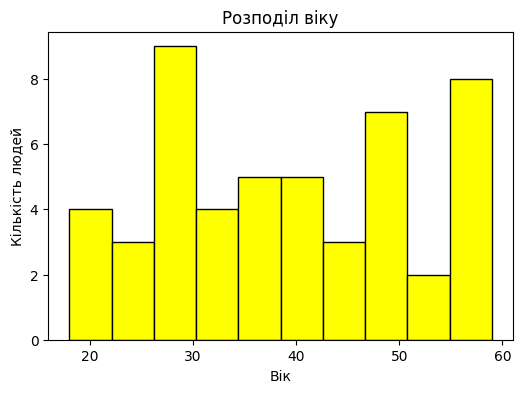

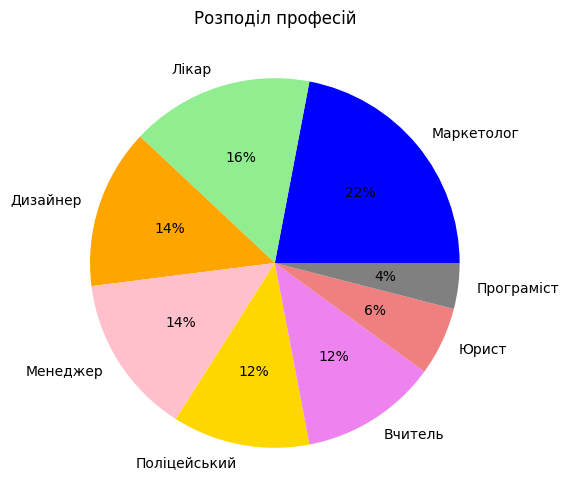

In [65]:
#діаграми

# для віку

plt.figure(figsize=(6, 4))
plt.hist(merged['Age'], bins=10, color='yellow', edgecolor='black')
plt.title('Розподіл віку')
plt.xlabel('Вік')
plt.ylabel('Кількість людей')
plt.show()

# для професій
occupation_counts = merged['Occupation'].value_counts()

plt.figure(figsize=(6, 6))
plt.pie(occupation_counts, labels=occupation_counts.index, autopct='%.0f%%',
        colors=['blue', 'lightgreen', 'orange', 'pink', 'gold', 'violet', 'lightcoral', 'gray'])
plt.title('Розподіл професій')
plt.show()